In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import arviz as az
import pymc as pm

In [4]:
from bayesic_offense_defense import team_ids, build_model

In [5]:
home_team_name = "Golden State Warriors" 
away_team_name = "Boston Celtics"

home_team_idx_new = team_ids[home_team_name]
away_team_idx_new = team_ids[away_team_name]
idata = az.from_netcdf("home_and_away.nc")
model = build_model()
with model:
    pm.set_data(
        {
            "home_idx_data": [home_team_idx_new],
            "away_idx_data": [away_team_idx_new],
            "obs_home_points_data": [0],
            "obs_away_points_data": [0],
        }
    )

    # Sample from the posterior predictive
    ppc_idata = pm.sample_posterior_predictive(
        idata,
        var_names=["home_team_points", "away_team_points"],
    )

home_scores = ppc_idata.posterior_predictive["home_team_points"]
away_scores = ppc_idata.posterior_predictive["away_team_points"]

home_scores_flat = home_scores.values.flatten()
away_scores_flat = away_scores.values.flatten()

pd = home_scores_flat - away_scores_flat

prob_home_wins = (pd > 0).mean()
predicted_spread = np.mean(pd)
spread_hdi = az.hdi(pd, hdi_prob=0.94)

print(f"Predicted Win Probability for {home_team_name} (home): {prob_home_wins:.2%}")
print(f"Predicted Spread: {home_team_name} by {predicted_spread:.2f} points")
print(f"94% HDI for spread: [{spread_hdi[0]:.2f}, {spread_hdi[1]:.2f}]")



Sampling: [away_team_points, home_team_points]


/Users/prithaj/Desktop/code/bayesketball/.venv/lib/python3.14t/site-packages/rich/live.py:256: UserWarning: install
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Predicted Win Probability for Golden State Warriors (home): 52.96%
Predicted Spread: Golden State Warriors by 0.84 points
94% HDI for spread: [-33.95, 35.36]


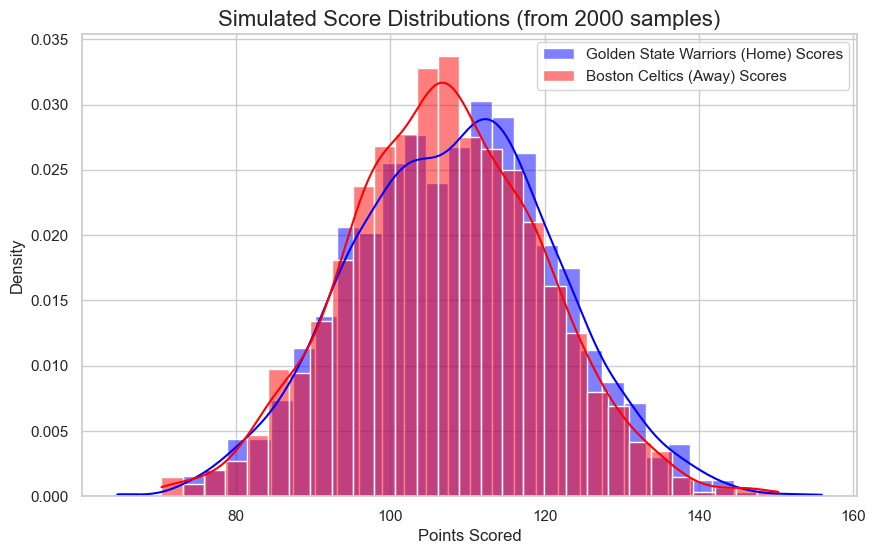

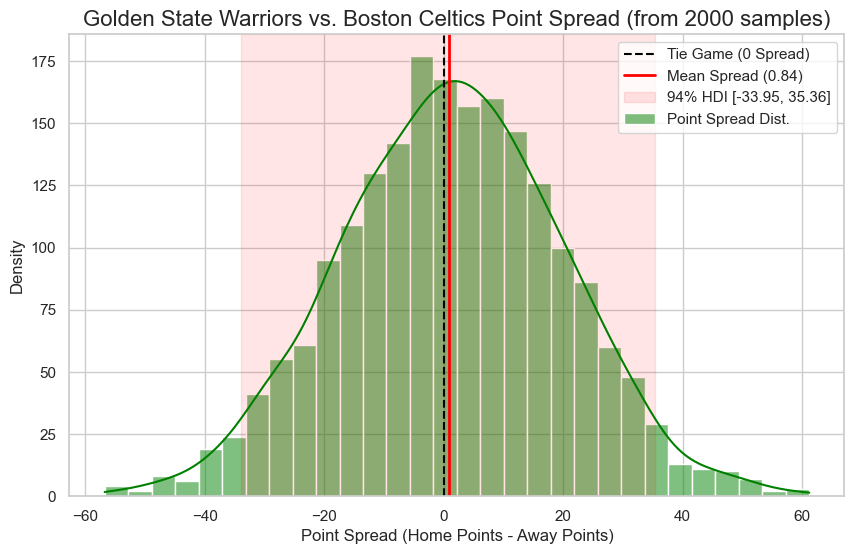

In [6]:
# GPT slop

n_plot_samples = 2000


if len(home_scores_flat) > n_plot_samples:
    # Get a random list of indices
    sample_indices = np.random.choice(len(home_scores_flat), n_plot_samples, replace=False)
    
    # Use the indices to create new, smaller arrays for plotting
    home_scores_plot = home_scores_flat[sample_indices]
    away_scores_plot = away_scores_flat[sample_indices]
    point_spread_plot = pd[sample_indices]
else:
    # If we have few samples, just plot them all
    home_scores_plot = home_scores_flat
    away_scores_plot = away_scores_flat
    point_spread_plot = pd

# --- 8. Visualize (using the new _plot arrays) ---
sns.set_theme(style="whitegrid")

# --- PLOT 1: Overlaid Score Distributions ---
plt.figure(figsize=(10, 6))
sns.histplot(
    home_scores_plot,  # <-- Use the sample
    kde=True, 
    label=f"{home_team_name} (Home) Scores", 
    color="blue",
    stat="density"
)
sns.histplot(
    away_scores_plot, # <-- Use the sample
    kde=True,
    label=f"{away_team_name} (Away) Scores",
    color="red",
    stat="density"
)
plt.title("Simulated Score Distributions (from 2000 samples)", fontsize=16)
plt.xlabel("Points Scored")
plt.ylabel("Density")
plt.legend()
plt.show()


# --- PLOT 2: Point Spread Distribution ---
plt.figure(figsize=(10, 6))
sns.histplot(point_spread_plot, kde=True, label="Point Spread Dist.", color="green") # <-- Use the sample

# Add lines for stats (these still use the full, accurate data)
plt.axvline(x=0, color="black", linestyle="--", label="Tie Game (0 Spread)")
plt.axvline(
    x=predicted_spread,
    color="red",
    linestyle="-",
    linewidth=2,
    label=f"Mean Spread ({predicted_spread:.2f})",
)
plt.axvspan(
    spread_hdi[0],
    spread_hdi[1],
    color="red",
    alpha=0.1,
    label=f"94% HDI [{spread_hdi[0]:.2f}, {spread_hdi[1]:.2f}]",
)

plt.title(f"{home_team_name} vs. {away_team_name} Point Spread (from 2000 samples)", fontsize=16)
plt.xlabel("Point Spread (Home Points - Away Points)")
plt.ylabel("Density")
plt.legend()
plt.show()